# ProjectAI Group 20: Plant Subspecies Image Classification

This project applies Convolutional Neural Networks (CNN) to classify plant subspecies using image data.

The selected domain is **Plant Subspecies**, and the dataset contains five flower classes:

- Daisy
- Dandelion
- Roses
- Sunflowers
- Tulips

The project follows three main stages: data preparation, data modelling, and data analysis.

## Dataset Download

The TensorFlow flower dataset is downloaded from an official online archive. This dataset contains flower images that will be used for plant subspecies classification.

In [ ]:
import tensorflow as tf
import os
import pathlib

# Download the official tensorflow flower archive
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir).parent / 'flower_photos'

print(f"✅ Raw photos successfully downloaded to: {data_dir}")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
✅ Raw photos successfully downloaded to: /root/.keras/datasets/flower_photos


## Data Preparation and Dataset Splitting

The dataset is extracted and prepared into training, validation, and testing datasets.

All images are resized to **224 × 224 pixels** because this input size is suitable for CNN architectures such as ResNet50, DenseNet121, and MobileNetV3.

The dataset is split into:

- 70% training data
- 15% validation data
- 15% testing data

Prefetching is also applied to improve training performance.

In [ ]:
import tensorflow as tf
import os
import tarfile

# 1. Force download and clean extraction to guarantee folder structure
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
local_tgz = tf.keras.utils.get_file('flower_photos.tgz', origin=url)

# Extract it manually to ensure classes are subdirectories
extract_path = "/content/fresh_dataset"
if not os.path.exists(extract_path):
    with tarfile.open(local_tgz, "r:gz") as tar:
        tar.extractall(path=extract_path)

# Correct source directory where class subfolders live
source_dir = os.path.join(extract_path, "flower_photos")

# 2. Pipeline Configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("--- Processing & Creating Training Dataset (70%) ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    source_dir,
    validation_split=0.30,   # Reserve 30% total for validation/testing combined
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\n--- Processing Remaining Data for Val & Test Splits ---")
remaining_ds = tf.keras.utils.image_dataset_from_directory(
    source_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Split the remaining 30% into equal 15% validation and 15% testing sets [cite: 7]
cardinality = tf.data.experimental.cardinality(remaining_ds).numpy()
val_batches = cardinality // 2

val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

# Optimize memory pipeline configurations
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("\n📊 Final Verification Check:")
print(f"✅ Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"✅ Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"✅ Testing batches: {tf.data.experimental.cardinality(test_ds).numpy()}")
print("\n🚀 DATASET PREPARATION COMPLETE! Ready to hand off to your team.")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/tmp/ipykernel_1655/1090567830.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


--- Processing & Creating Training Dataset (70%) ---
Found 3670 files belonging to 5 classes.
Using 2569 files for training.

--- Processing Remaining Data for Val & Test Splits ---
Found 3670 files belonging to 5 classes.
Using 1101 files for validation.

📊 Final Verification Check:
✅ Training batches: 81
✅ Validation batches: 17
✅ Testing batches: 18

🚀 DATASET PREPARATION COMPLETE! Ready to hand off to your team.


## Importing Deep Learning Libraries

TensorFlow and Keras libraries are imported to build and train CNN models.

The three CNN architectures used in this project are:

- ResNet50
- DenseNet121
- MobileNetV3Large

These models are used with transfer learning.

In [ ]:
import tensorflow as tf
import time

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications import MobileNetV3Large

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.models import Model

## Defining Class Labels

The dataset contains five flower classes. These class names are stored in a list and the number of classes is calculated.

This value is later used in the output layer of the neural network model.

In [ ]:
class_names = [
    'daisy',
    'dandelion',
    'roses',
    'sunflowers',
    'tulips'
]

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


## Building the Transfer Learning Model

A reusable function is created to build CNN models using transfer learning.

The base model is frozen so that the pre-trained ImageNet weights are not updated during training. A new classification head is added using Global Average Pooling, Dropout, and a Dense output layer with Softmax activation.

In [ ]:
def build_model(base_model):

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Creating the ResNet50 Model

The ResNet50 model is created using pre-trained ImageNet weights.

The top classification layer is removed and replaced with a custom output layer for the five flower classes.

In [ ]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = build_model(resnet_base)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Training the ResNet50 Model

The ResNet50 model is trained using the training dataset and validated using the validation dataset.

The training time is recorded so that it can be compared with other models.

In [ ]:
start_time = time.time()

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

resnet_time = time.time() - start_time

print("ResNet50 Training Time:", resnet_time)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 212ms/step - accuracy: 0.6812 - loss: 0.8961 - val_accuracy: 0.8254 - val_loss: 0.4693
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8326 - loss: 0.4576 - val_accuracy: 0.8364 - val_loss: 0.4487
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.8743 - loss: 0.3673 - val_accuracy: 0.8640 - val_loss: 0.3889
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.8828 - loss: 0.3138 - val_accuracy: 0.8787 - val_loss: 0.3251
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9089 - loss: 0.2584 - val_accuracy: 0.8768 - val_loss: 0.3208
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.9144 - loss: 0.2387 - val_accuracy: 0.8695 - val_loss: 0.3661
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.9299 - loss: 0.2039 - val_accuracy: 0.8934 - val_loss: 0.3211
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.9334 - loss: 0.1837 - val_accuracy: 0.

## Creating the DenseNet121 Model

The DenseNet121 model is created using pre-trained ImageNet weights.

This model is used to compare its performance against ResNet50 and MobileNetV3.

In [ ]:
dense_base = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

dense_model = build_model(dense_base)

dense_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,042,629 (26.87 MB)

 Trainable params: 5,125 (20.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Training the DenseNet121 Model

The DenseNet121 model is trained for plant subspecies classification.

The training history and training time are saved for later evaluation and comparison.

In [ ]:
start_time = time.time()

history_dense = dense_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

dense_time = time.time() - start_time

print("DenseNet121 Training Time:", dense_time)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 64s 435ms/step - accuracy: 0.3581 - loss: 5.1300 - val_accuracy: 0.5956 - val_loss: 1.7357
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.5185 - loss: 2.9007 - val_accuracy: 0.6654 - val_loss: 1.5096
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.5831 - loss: 1.9928 - val_accuracy: 0.6710 - val_loss: 1.2721
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.6248 - loss: 1.6358 - val_accuracy: 0.6967 - val_loss: 1.1456
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.6364 - loss: 1.4078 - val_accuracy: 0.7004 - val_loss: 1.0693
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.6532 - loss: 1.2808 - val_accuracy: 0.7040 - val_loss: 1.0779
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.6575 - loss: 1.2340 - val_accuracy: 0.7298 - val_loss: 0.9222
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.6711 - loss: 1.1630 - val_accuracy: 0

## Creating the MobileNetV3 Model

The MobileNetV3Large model is created using transfer learning.

MobileNetV3 is a lightweight CNN model, so it is expected to train faster and use fewer parameters compared to larger models.

In [ ]:
mobile_base = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobile_model = build_model(mobile_base)

mobile_model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,001,157 (11.45 MB)

 Trainable params: 4,805 (18.77 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

## Training the MobileNetV3 Model

The MobileNetV3 model is trained using the same training and validation datasets.

The training time is recorded to compare its efficiency with ResNet50 and DenseNet121.

In [ ]:
start_time = time.time()

history_mobile = mobile_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

mobile_time = time.time() - start_time

print("MobileNetV3 Training Time:", mobile_time)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 295ms/step - accuracy: 0.6493 - loss: 0.9104 - val_accuracy: 0.8474 - val_loss: 0.4233
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8459 - loss: 0.4514 - val_accuracy: 0.8824 - val_loss: 0.3374
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8828 - loss: 0.3564 - val_accuracy: 0.8989 - val_loss: 0.3102
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.8972 - loss: 0.2915 - val_accuracy: 0.9118 - val_loss: 0.2761
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9116 - loss: 0.2639 - val_accuracy: 0.9136 - val_loss: 0.2632
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9198 - loss: 0.2309 - val_accuracy: 0.9099 - val_loss: 0.2683
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9260 - loss: 0.2141 - val_accuracy: 0.9118 - val_loss: 0.2494
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9292 - loss: 0.2079 - val_accuracy: 0.9062 -

## Hyperparameter Tuning

Hyperparameter tuning is considered by adjusting the learning rate and dropout value.

The learning rate controls how fast the model learns, while dropout helps reduce overfitting.

In [ ]:
optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001
)

Dropout(0.5)

<Dropout name=dropout_3, built=True>

## Initial Model Evaluation

Each trained model is evaluated using the testing dataset.

This provides an initial test loss and test accuracy for ResNet50, DenseNet121, and MobileNetV3.

In [ ]:
resnet_eval = resnet_model.evaluate(test_ds)

dense_eval = dense_model.evaluate(test_ds)

mobile_eval = mobile_model.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.8725 - loss: 0.4900
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 757ms/step - accuracy: 0.7451 - loss: 0.7470
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 698ms/step - accuracy: 0.8869 - loss: 0.4326


## Importing Data Analysis Libraries

Additional libraries are imported for model evaluation and visualization.

These libraries are used to create accuracy graphs, loss graphs, classification reports, confusion matrices, and mAP scores.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import average_precision_score

## Function for Accuracy and Loss Graphs

A function is created to plot the training and validation accuracy as well as training and validation loss.

These graphs help identify whether the model is learning properly or overfitting.

In [ ]:
def plot_training_history(history, model_name):
    # Accuracy graph
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss graph
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## Visualizing Training Performance

The training history of each model is visualized.

This allows comparison of the accuracy and loss performance for ResNet50, DenseNet121, and MobileNetV3.

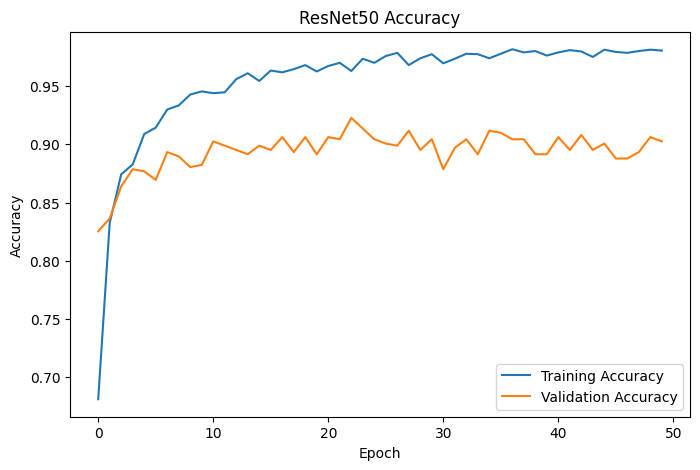

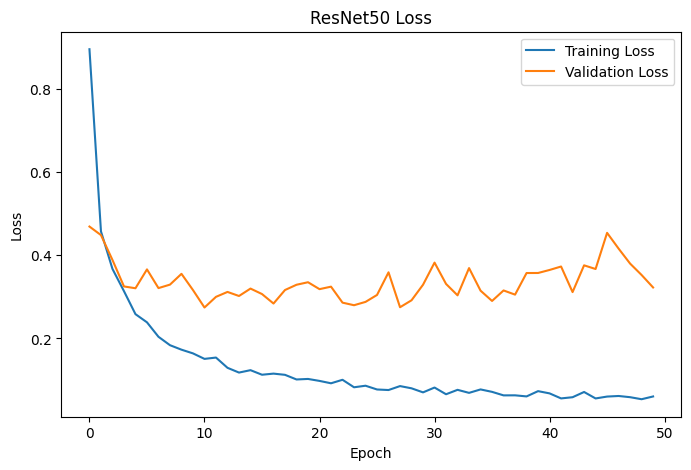

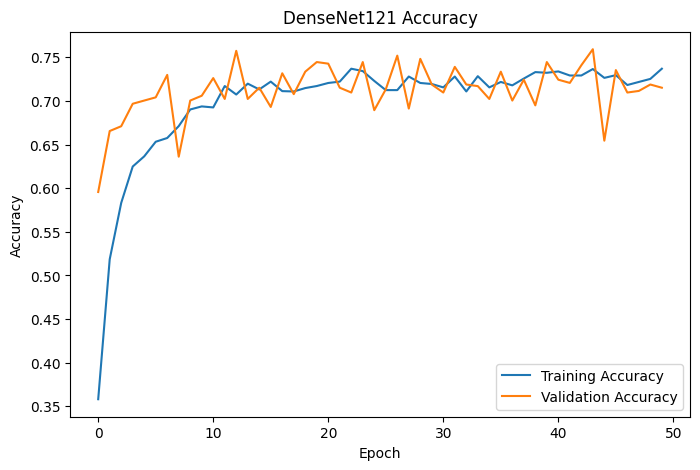

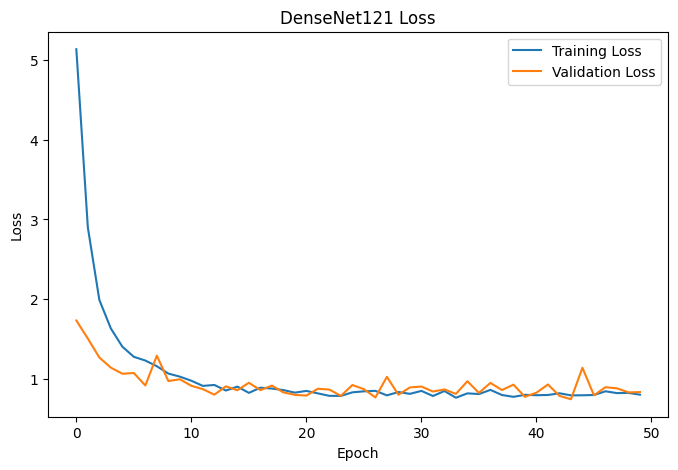

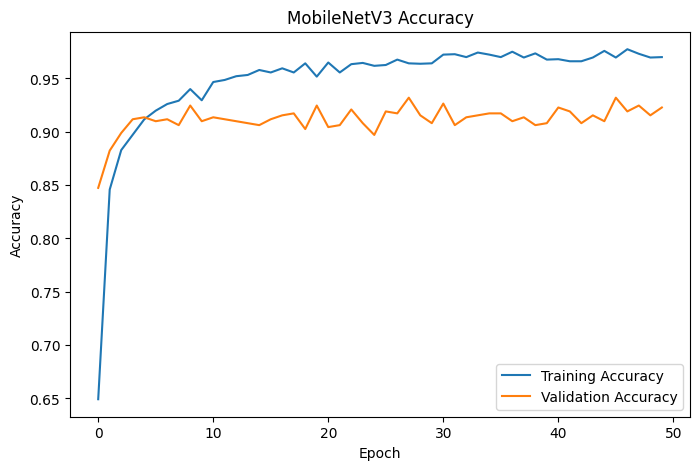

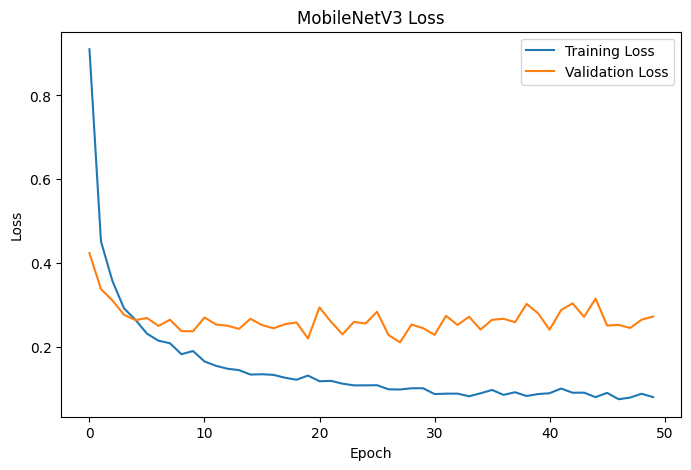

In [ ]:
plot_training_history(history_resnet, "ResNet50")
plot_training_history(history_dense, "DenseNet121")
plot_training_history(history_mobile, "MobileNetV3")

## Preparing True Labels

The actual labels from the testing dataset are extracted.

These labels are needed to compare the model predictions with the correct answers.

In [ ]:
y_true = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

## Model Evaluation Function

A function is created to evaluate each trained model.

This function produces:

- Classification report
- Confusion matrix
- Test accuracy
- mAP score

The confusion matrix helps show which flower classes were correctly or incorrectly classified.

In [ ]:
def evaluate_model(model, model_name):
    y_pred_prob = model.predict(test_ds)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print(f"Classification Report for {model_name}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    test_loss, test_accuracy = model.evaluate(test_ds)

    mAP = average_precision_score(
        tf.keras.utils.to_categorical(y_true, num_classes=num_classes),
        y_pred_prob,
        average='macro'
    )

    return test_accuracy, mAP

## Evaluating All Models

The evaluation function is applied to all three CNN models.

The accuracy and mAP values are stored for the final comparison table.

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
Classification Report for ResNet50
              precision    recall  f1-score   support

       daisy       0.10      0.11      0.11        83
   dandelion       0.24      0.24      0.24       143
       roses       0.15      0.15      0.15       100
  sunflowers       0.16      0.17      0.17       102
      tulips       0.27      0.25      0.26       129

    accuracy                           0.19       557
   macro avg       0.18      0.18      0.18       557
weighted avg       0.20      0.19      0.19       557



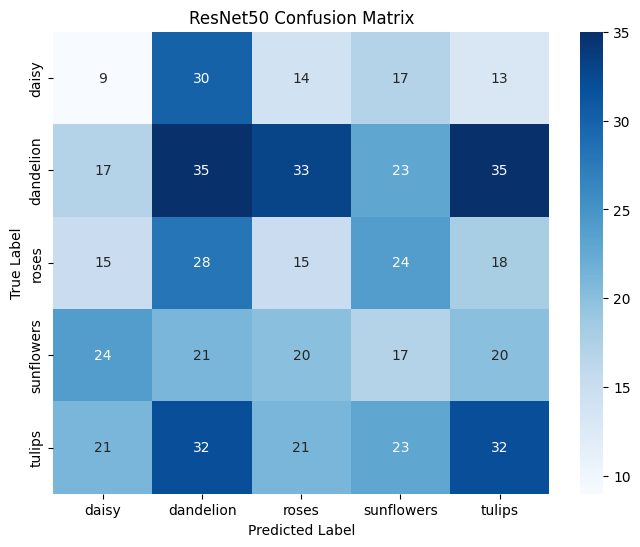

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8833 - loss: 0.4649
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Classification Report for DenseNet121
              precision    recall  f1-score   support

       daisy       0.25      0.18      0.21        83
   dandelion       0.27      0.29      0.28       143
       roses       0.20      0.21      0.21       100
  sunflowers       0.22      0.25      0.23       102
      tulips       0.21      0.20      0.20       129

    accuracy                           0.23       557
   macro avg       0.23      0.23      0.23       557
weighted avg       0.23      0.23      0.23       557



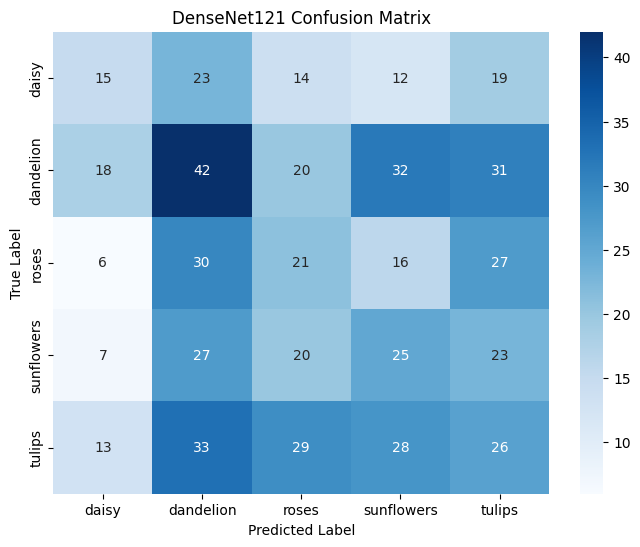

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7415 - loss: 0.6961
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
Classification Report for MobileNetV3
              precision    recall  f1-score   support

       daisy       0.12      0.11      0.11        83
   dandelion       0.27      0.29      0.28       143
       roses       0.16      0.19      0.18       100
  sunflowers       0.22      0.22      0.22       102
      tulips       0.15      0.13      0.14       129

    accuracy                           0.19       557
   macro avg       0.18      0.19      0.19       557
weighted avg       0.19      0.19      0.19       557



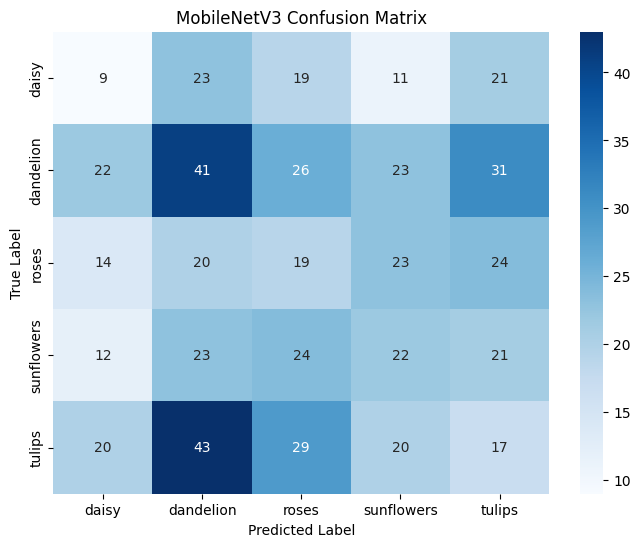

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8851 - loss: 0.4172


## Counting Model Parameters

The number of parameters for each model is counted.

This is important because the final conclusion must consider not only accuracy and mAP, but also model size and efficiency.

In [ ]:
resnet_params = resnet_model.count_params()
dense_params = dense_model.count_params()
mobile_params = mobile_model.count_params()

print("ResNet50:", resnet_params)
print("DenseNet121:", dense_params)
print("MobileNetV3:", mobile_params)

ResNet50: 23597957
DenseNet121: 7042629
MobileNetV3: 3001157


## Final Model Comparison Table

A comparison table is created to compare all three models based on:

- Accuracy
- mAP
- Training time
- Number of parameters

This table makes it easier to decide which model performs best overall.

In [ ]:
results = pd.DataFrame({
    "Model": ["ResNet50", "DenseNet121", "MobileNetV3"],
    "Accuracy": [resnet_accuracy, dense_accuracy, mobile_accuracy],
    "mAP": [resnet_map, dense_map, mobile_map],
    "Training Time (seconds)": [resnet_time, dense_time, mobile_time],
    "Parameters": [resnet_params, dense_params, mobile_params]
})

results

,Model,Accuracy,mAP,Training Time (seconds),Parameters
0,ResNet50,0.883303,0.199219,480.527757,23597957
1,DenseNet121,0.741472,0.225227,497.907665,7042629
2,MobileNetV3,0.885099,0.200779,351.258301,3001157


## Selecting the Best Model

The best model is selected based on accuracy and mAP.

The final decision also considers training time and number of parameters.

In [ ]:
best_model = results.sort_values(
    by=["Accuracy", "mAP"],
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model                      MobileNetV3
Accuracy                      0.885099
mAP                           0.200779
Training Time (seconds)     351.258301
Parameters                     3001157
Name: 2, dtype: object
